In [1]:
import os
import gymnasium as gym
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils as utils
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

In [2]:
from glob import glob
from tqdm import tqdm
from flow_package.multi_df_env_v2 import MultiDfEnvV2, EnvConfig
from network_v2 import DeepFlowNetworkV2

In [3]:
path = "../data/train/binary"
files = glob(os.path.join(path, "*.csv.gz"))

dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs)

reward_list = [0.5, 1.5, -1.0, -0.5, -1.0]

config = EnvConfig(
    df_data=df,
    label_column="Label",
    reward_list=reward_list,
    max_steps=10_000,
    normalize_method="min-max",
    rolling_window=10,
)

def make_envs(config):
    def _init():
        return MultiDfEnvV2(config)
    return _init

env_fn = [make_envs(config) for _ in range(7)]
envs = gym.vector.SyncVectorEnv(env_fn)

In [4]:
n_states = envs.observation_space.shape[1]
n_actions = envs.action_space[0].n
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(n_states, n_actions)

88 10


In [5]:
policy_net = DeepFlowNetworkV2(n_states, n_actions).to(device)
target_net = DeepFlowNetworkV2(n_states, n_actions).to(device)

target_net.load_state_dict(policy_net.state_dict())

cm_memory = []

optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)

from deep_learn import ReplayMemory, Transaction, TransactionBatch
from torch.amp import GradScaler

memory = ReplayMemory(100000)
BATCH_SIZE = 128
GAMMA = 0.999
F_LOSS = nn.SmoothL1Loss()
scaler = GradScaler()

In [6]:
def select_action(state_tensor: torch.Tensor):
    global envs, policy_net, steps_done

    random_float_list = np.random.rand(len(state_tensor))

    action_list = []
    with torch.no_grad():
        net_action = policy_net(state_tensor).argmax(dim=1)
    
    random_action = envs.action_space.sample()
    random_action_tensor = torch.tensor(random_action, device=device)

    mask = torch.tensor(random_float_list > 0.5, device=device)

    action_tensor = torch.where(mask, net_action, random_action_tensor)
    return action_tensor.unsqueeze(1)

In [7]:
def optimize_model():
    transitions = memory.sample(BATCH_SIZE)
    batch = Transaction(*zip(*transitions))
    # バッチを (B, n_states) のテンソルに変換（float32, device）
    state_batch = torch.tensor(batch.state, device=device)
    action_batch = torch.cat(batch.action).to(device).long().unsqueeze(1)
    reward_batch = torch.cat(batch.reward).to(device).float()

    non_final_mask = torch.tensor([s is not None for s in batch.next_state], device=device, dtype=torch.bool)
    non_final_next_states = [s for s in batch.next_state if s is not None]

    # next_state_batch が空の場合は None にして処理をスキップする
    if len(non_final_next_states) > 0:
        next_state_batch = torch.tensor(non_final_next_states, device=device)
    else:
        next_state_batch = None

    # 損失計算
    state_action = policy_net(state_batch)
    state_action_values = state_action.gather(1, action_batch)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    if next_state_batch is not None:
        with torch.no_grad():
            next_q = target_net(next_state_batch)
            next_state_values[non_final_mask] = next_q.max(1).values.float()
    expected_state_action_values = reward_batch + GAMMA * next_state_values
    loss = F_LOSS(state_action_values, expected_state_action_values.unsqueeze(1))

    # 最適化
    optimizer.zero_grad()
    if scaler is not None:
        scaler.scale(loss).backward()
        utils.clip_grad_value_(policy_net.parameters(), 1000)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        utils.clip_grad_value_(policy_net.parameters(), 1000)
        optimizer.step()
    
    return loss.item()

In [ ]:
from IPython.display import clear_output
def moving_average(data, window_size):
    """移動平均を計算"""
    if window_size <= 1 or len(data) == 0:
        return np.array(data)
    if len(data) < window_size:
        window_size = max(1, len(data))
    weights = np.ones(window_size) / window_size
    return np.convolve(data, weights, mode='valid')

def enhanced_plot_loss(loss_list, episode=None):
    """改良版のLossプロット関数"""
    clear_output(wait=True)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. 全体のLoss推移
    axes[0].plot(loss_list, alpha=0.7, color='blue', label='Raw')
    if len(loss_list) > 10:
        smooth = moving_average(loss_list, min(50, len(loss_list)//4))
        axes[0].plot(range(len(smooth)), smooth, color='red', linewidth=2, label='Smooth')
    axes[0].set_title(f'Training Loss (Step {len(loss_list)})')
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # 2. 最近のLoss（最後の200ステップ）
    recent = loss_list[-200:] if len(loss_list) > 200 else loss_list
    axes[1].plot(recent, color='green', linewidth=2)
    axes[1].set_title('Recent Loss')
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Loss')
    axes[1].grid(True)
    
    # 3. 統計情報
    axes[2].axis('off')
    current_loss = loss_list[-1] if loss_list else 0
    min_loss = min(loss_list) if loss_list else 0
    avg_loss = np.mean(loss_list) if loss_list else 0
    
    stats = f"""
    Current Loss: {current_loss:.4f}
    Min Loss: {min_loss:.4f}
    Avg Loss: {avg_loss:.4f}
    
    Steps: {len(loss_list)}
    Memory: {len(memory)}
    """
    axes[2].text(0.1, 0.5, stats, fontsize=12, verticalalignment='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))
    
    plt.tight_layout()
    plt.show()

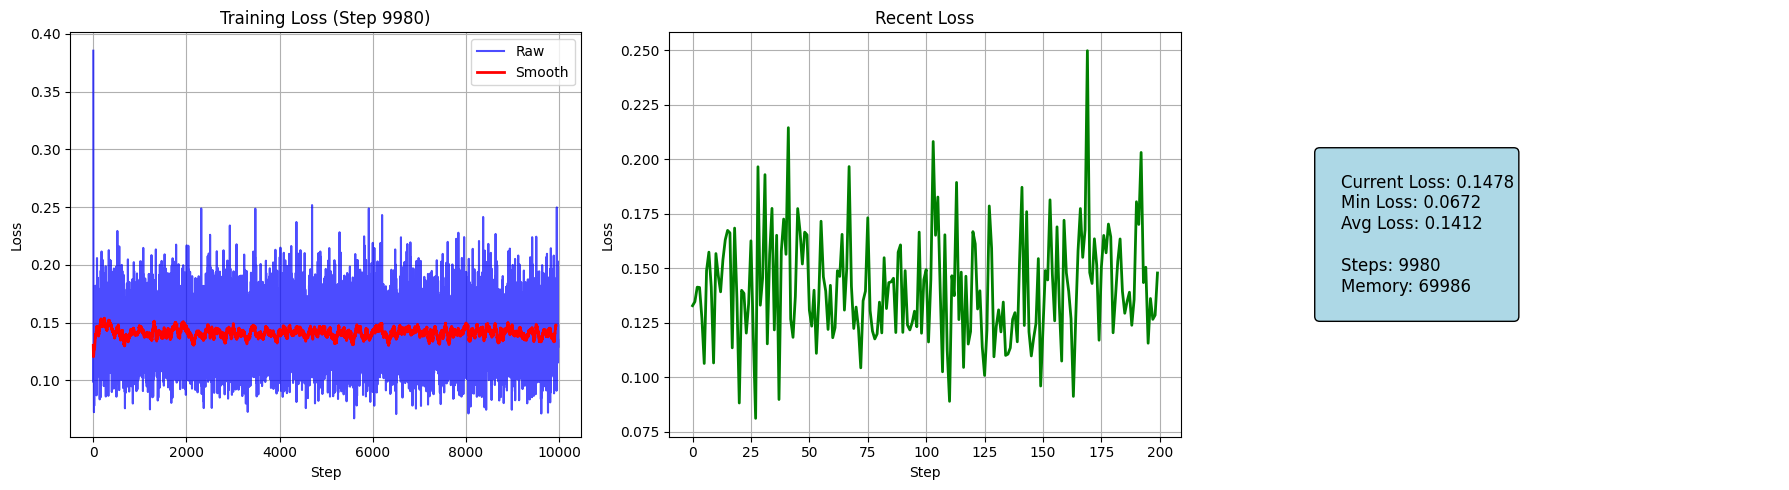

In [9]:
obs, infos = envs.reset()
# print(infos["data_length"])
obs_tensor = torch.tensor(obs, device=device)
loss_list = []
count = 0

for i in range(10_000):
    actions = select_action(obs_tensor)
    next_obs, rewards, terminated, truncated, infos = envs.step(actions)
    # print(f'\r{i+1:4d} {infos["episode"]} {infos["steps"]} {terminated}', end='')

    preserve_rewards = torch.tensor(
        [[float(r)] for r in rewards],
        dtype=torch.float32,
        device=device,
    )

    memory.push_batch(TransactionBatch(obs, actions, next_obs, preserve_rewards))
    if len(memory) > BATCH_SIZE:
        count += 1
        loss = optimize_model()
        loss_list.append(loss)
        if count % 5 == 0:
            enhanced_plot_loss(loss_list)

    obs_tensor = torch.tensor(next_obs, device=device)


In [10]:
torch.save(policy_net.state_dict(), "policy_net.pth")
torch.save(target_net.state_dict(), "target_net.pth")


In [11]:
test_path = "../data/test/binary"
test_files = glob(os.path.join(test_path, "*.csv.gz"))

test_dfs = [pd.read_csv(f) for f in test_files]
test_df = pd.concat(test_dfs)

print(test_df.columns)

test_config = EnvConfig(
    df_data=test_df,
    label_column="Label",
    reward_list=reward_list,
    max_steps=10_000,
    normalize_method="min-max",
    test_mode=True,
)

def make_envs(config):
    def _init():
        return MultiDfEnvV2(config)
    return _init

test_env_fn = [make_envs(test_config) for _ in range(7)]
test_envs = gym.vector.SyncVectorEnv(test_env_fn)



Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s',
       'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
       'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
       'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Down/Up Ratio',
       'Average Packet Size', 'Avg Fwd Segme

In [12]:
def test_full_dataset_single_episode(network, df_data, reward_list, device=device):
    """
    全データセットを1回のエピソードで処理する関数
    """
    network.eval()
    
    # 環境設定（全データを使用）
    config = EnvConfig(
        df_data=df_data,
        label_column="Label",
        reward_list=reward_list,
        max_steps=len(df_data),  # 全データ数に設定
        normalize_method="min-max",
        rolling_window=10,
        test_mode=True,
    )
    
    # 単一環境を作成
    env = MultiDfEnvV2(config)
    
    # エピソード開始
    obs, info = env.reset()
    total_reward = 0
    step_count = 0
    correct_predictions = 0
    predictions = []
    true_labels = []
    action_history = []
    reward_history = []
    confidence_history = []
    
    print(f"全データセット処理開始: {len(df_data)} サンプル")
    
    # tqdmで進捗管理を追加
    for step in tqdm(range(len(df_data)), desc="Processing dataset", unit="sample"):
        # 状態をテンソルに変換
        obs_tensor = torch.tensor(obs, device=device, dtype=torch.float32)
        
        # 最適行動を選択（探索なし）
        with torch.no_grad():
            q_values = network(obs_tensor)
            action = q_values.argmax().item()
            confidence = F.softmax(q_values, dim=0).max().item()
        
        # 行動を実行
        next_obs, reward, terminated, truncated, info = env.step(action)
        
        # 結果を記録
        total_reward += reward
        step_count += 1
        predictions.append(action)
        action_history.append(action)
        reward_history.append(reward)
        confidence_history.append(confidence)
        
        # 正解ラベルを取得（環境から）
        if 'confusion_matrix_index' in info:
            true_label = info['confusion_matrix_index'][1]  # 実際のラベル
            true_labels.append(true_label)
            if action == true_label:
                correct_predictions += 1
        
        obs = next_obs
        
        # エピソード終了条件（通常は全データ処理後に終了）
        if terminated or truncated:
            print(f"  エピソード終了: step {step}")
            break
    
    # 結果を計算
    accuracy = correct_predictions / step_count if step_count > 0 else 0
    avg_reward_per_step = total_reward / step_count if step_count > 0 else 0
    avg_confidence = np.mean(confidence_history) if confidence_history else 0
    
    print(f"\n=== 全データセット処理結果 ===")
    print(f"処理サンプル数: {step_count}")
    print(f"総報酬: {total_reward:.2f}")
    print(f"平均報酬/ステップ: {avg_reward_per_step:.4f}")
    print(f"精度: {accuracy:.4f}")
    print(f"平均信頼度: {avg_confidence:.4f}")
    
    return {
        'total_reward': total_reward,
        'accuracy': accuracy,
        'step_count': step_count,
        'avg_reward_per_step': avg_reward_per_step,
        'avg_confidence': avg_confidence,
        'predictions': predictions,
        'true_labels': true_labels,
        'action_history': action_history,
        'reward_history': reward_history,
        'confidence_history': confidence_history
    }


In [13]:
def test_full_dataset_batch_processing(network, df_data, batch_size=1000, device=device):
    """
    全データセットをバッチで効率的に処理する関数
    """
    network.eval()
    
    # データを準備
    features = df_data.drop('Label', axis=1).values
    true_labels = df_data['Label'].values
    
    predictions = []
    confidences = []
    total_reward = 0
    
    print(f"バッチ処理開始: {len(df_data)} サンプル, バッチサイズ: {batch_size}")
    
    # tqdmで進捗管理を追加
    for i in tqdm(range(0, len(features), batch_size), desc="Batch processing", unit="batch"):
        batch_features = features[i:i+batch_size]
        batch_labels = true_labels[i:i+batch_size]
        
        # バッチをテンソルに変換
        batch_tensor = torch.tensor(batch_features, device=device, dtype=torch.float32)
        
        # 予測実行
        with torch.no_grad():
            q_values = network(batch_tensor)
            batch_predictions = q_values.argmax(dim=1).cpu().numpy()
            batch_confidences = F.softmax(q_values, dim=1).max(dim=1)[0].cpu().numpy()
        
        # 報酬を計算（簡易版）
        batch_rewards = []
        for pred, true_label in zip(batch_predictions, batch_labels):
            if pred == true_label:
                reward = 1.0  # 正解
            else:
                reward = -0.1  # 不正解
            batch_rewards.append(reward)
        
        total_reward += sum(batch_rewards)
        predictions.extend(batch_predictions)
        confidences.extend(batch_confidences)
    
    # 結果を計算
    accuracy = (np.array(predictions) == true_labels).mean()
    avg_confidence = np.mean(confidences)
    avg_reward_per_sample = total_reward / len(df_data)
    
    print(f"\n=== バッチ処理結果 ===")
    print(f"処理サンプル数: {len(df_data)}")
    print(f"総報酬: {total_reward:.2f}")
    print(f"平均報酬/サンプル: {avg_reward_per_sample:.4f}")
    print(f"精度: {accuracy:.4f}")
    print(f"平均信頼度: {avg_confidence:.4f}")
    
    return {
        'total_reward': total_reward,
        'accuracy': accuracy,
        'avg_reward_per_sample': avg_reward_per_sample,
        'avg_confidence': avg_confidence,
        'predictions': predictions,
        'true_labels': true_labels.tolist(),
        'confidences': confidences
    }


In [14]:
import seaborn as sns

# セル24: 結果の詳細分析
def analyze_full_dataset_results(results):
    """全データセット処理結果を詳細分析"""
    
    predictions = results['predictions']
    true_labels = results['true_labels']
    confidences = results.get('confidences', [])
    
    # 混同行列
    from sklearn.metrics import confusion_matrix, classification_report
    
    cm = confusion_matrix(true_labels, predictions)
    
    print("\n=== 詳細分析 ===")
    print(f"混同行列:")
    print(cm)
    
    # 分類レポート
    print(f"\n分類レポート:")
    print(classification_report(true_labels, predictions))
    
    # 信頼度分析
    if confidences:
        print(f"\n信頼度分析:")
        print(f"  平均信頼度: {np.mean(confidences):.4f}")
        print(f"  信頼度標準偏差: {np.std(confidences):.4f}")
        print(f"  最小信頼度: {np.min(confidences):.4f}")
        print(f"  最大信頼度: {np.max(confidences):.4f}")
        
        # 信頼度分布
        plt.figure(figsize=(10, 6))
        plt.hist(confidences, bins=50, alpha=0.7, edgecolor='black')
        plt.title('Confidence Distribution')
        plt.xlabel('Confidence')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        plt.show()
    
    # 混同行列を可視化
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return cm


In [15]:
# セル25: 実行
print("全データセットを1エピソードで処理中...")


全データセットを1エピソードで処理中...


In [ ]:
# 方法1: 環境を使った処理（より現実的）
print("\n=== 方法1: 環境を使った処理 ===")
env_results = test_full_dataset_single_episode(policy_net, test_df, reward_list)



=== 方法1: 環境を使った処理 ===
全データセット処理開始: 629992 サンプル


Processing dataset:  58%|█████▊    | 366030/629992 [8:06:44<6:07:25, 11.97sample/s] 

In [ ]:
# 方法2: バッチ処理（より効率的）
print("\n=== 方法2: バッチ処理 ===")
batch_results = test_full_dataset_batch_processing(policy_net, test_df, batch_size=1000)



In [ ]:
# 結果を比較
print("\n=== 結果比較 ===")
print(f"環境処理 - 精度: {env_results['accuracy']:.4f}, 報酬: {env_results['total_reward']:.2f}")
print(f"バッチ処理 - 精度: {batch_results['accuracy']:.4f}, 報酬: {batch_results['total_reward']:.2f}")



In [ ]:
# 詳細分析
print("\n=== バッチ処理結果の詳細分析 ===")
analyze_full_dataset_results(batch_results)